In [4]:
driver1 = session.laps.pick_driver('VER').pick_fastest()
fl1_tel = driver1.get_car_data().add_distance().add_differential_distance().add_relative_distance().add_driver_ahead()#Position data
print(driver1)

c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\core.py:3022: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Time                      0 days 00:48:43.533000
Driver                                       VER
DriverNumber                                   1
LapTime                   0 days 00:01:29.065000
LapNumber                                   10.0
Stint                                        3.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:30.950000
Sector2Time               0 days 00:00:40.619000
Sector3Time               0 days 00:00:17.496000
Sector1SessionTime        0 days 00:47:45.418000
Sector2SessionTime        0 days 00:48:26.037000
Sector3SessionTime        0 days 00:48:43.533000
SpeedI1                                    278.0
SpeedI2                                    303.0
SpeedFL                                    270.0
SpeedST                                    304.0
IsPersonalBest                              True
Compound                                    SOFT
TyreLife            

In [1]:
from calendar import c
import re
import fastf1 as ff1
import pandas as pd
from datetime import date 
from fastf1 import utils
from matplotlib.offsetbox import OffsetImage,AnnotationBbox
from matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from helper import *

In [2]:
session = ff1.get_session(2025, 3, 'FP1')
session.load()


req         WARNING 	DEFAULT CACHE ENABLED! (327.68 MB) C:\Users\Danie\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Japanese Grand Prix - Practice 1 [v3.4.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '44', '55', '62', '63', '81', '

In [4]:

driver1 = session.laps.pick_driver('VER')

driver1_lap =  driver1[driver1.LapNumber==10]
#currentDriverLap1 =  laps.pick_fastest()
fl1_tel = driver1_lap.get_car_data().add_distance().add_differential_distance().add_relative_distance().add_driver_ahead()#Position data
#fl1_tel = currentDriverLap1.get_pos_data().add_driv
fl1_tel_xy = driver1_lap.get_pos_data().add_driver_ahead() #Position data
fl1_tel_xy['Time'] = fl1_tel_xy['Time'].dt.total_seconds()
# er_ahead()#Position data


driver2 = session.laps.pick_driver('TSU')

driver2_lap =  driver2[driver2.LapNumber==11]
#currentDriverLap2 =  laps.pick_fastest()
fl2_tel = driver2_lap.get_car_data().add_distance().add_differential_distance().add_relative_distance().add_driver_ahead()#Position data
fl2_tel_xy = driver2_lap.get_pos_data().add_driver_ahead() #Position data
fl2_tel_xy['Time'] = fl2_tel_xy['Time'].dt.total_seconds()


#fl1_tel.iloc[len(fl1_tel)]['Speed'] = 0
next_idx = fl1_tel.index.max() + 1 if len(fl1_tel) > 0 else 0
    
# Crear una fila con valores NaN
fl1_tel.loc[next_idx] = np.nan
fl1_tel.loc[next_idx,'Speed'] = fl1_tel.loc[next_idx-1,'Speed'] + 1
fl1_tel.loc[next_idx,'Distance'] = float(fl1_tel.loc[next_idx-1,'Distance']) + 15
fl1_tel.loc[next_idx,'Time'] = pd.Timedelta(driver1_lap.LapTime.values[0])
fl1_tel.loc[next_idx,'Brake'] = fl1_tel.loc[next_idx-1,'Brake']
fl1_tel.loc[next_idx,'Throttle'] = fl1_tel.loc[next_idx-1,'Throttle']
fl1_tel.loc[next_idx,'nGear'] = fl1_tel.loc[next_idx-1,'nGear']
print(pd.Timedelta(driver1_lap.LapTime.values[0]))
print(pd.Timedelta(driver2_lap.LapTime.values[0]))
#fl1_tel.iloc[len(fl1_tel)]['Speed'] = 0
next_idx = fl2_tel.index.max() + 1 if len(fl2_tel) > 0 else 0
    
# Crear una fila con valores NaN
fl2_tel.loc[next_idx] = np.nan
fl2_tel.loc[next_idx,'Speed'] = fl2_tel.loc[next_idx-1,'Speed'] + 1
fl2_tel.loc[next_idx,'Distance'] = float(fl2_tel.loc[next_idx-1,'Distance']) + 15
fl2_tel.loc[next_idx,'Time'] = pd.Timedelta(driver2_lap.LapTime.values[0])
fl2_tel.loc[next_idx,'Brake'] = fl2_tel.loc[next_idx-1,'Brake']
fl2_tel.loc[next_idx,'Throttle'] = fl2_tel.loc[next_idx-1,'Throttle']
fl2_tel.loc[next_idx,'nGear'] = fl2_tel.loc[next_idx-1,'nGear']


nueva_fila = {'Date':fl1_tel.loc[0,'Date'],	'RPM':fl1_tel.loc[0,'RPM'],	'Speed':fl1_tel.loc[0,'Speed']-1,	'nGear':fl1_tel.loc[0,'nGear'],	'Throttle':fl1_tel.loc[0,'Throttle'],	'Brake':fl1_tel.loc[0,'Brake'],	'DRS':fl1_tel.loc[0,'DRS'],	'Source':fl1_tel.loc[0,'Source'],	'Time':pd.Timedelta(0),	'SessionTime':fl1_tel.loc[0,'SessionTime'],	'Distance':0,	'DifferentialDistance':fl1_tel.loc[0,'DifferentialDistance'],	'RelativeDistance':0,	'DriverAhead':fl1_tel.loc[0,'DriverAhead'],	'DistanceToDriverAhead':fl1_tel.loc[0,'DistanceToDriverAhead'],}  # Ajusta según tus columnas
# Convertir la nueva fila en DataFrame
nueva_fila_df = pd.DataFrame([nueva_fila])
# Concatenar al inicio
fl1_tel = pd.concat([nueva_fila_df, fl1_tel]).reset_index(drop=True)


max_distance = fl2_tel['Distance'].max()

# Aplicar la normalización (x - min) / (max - min)
fl2_tel['RelativeDistance1'] = (fl2_tel['Distance'] - 0) / (max_distance - 0)

max_distance = fl1_tel['Distance'].max()
track_length = 5807
# Aplicar la normalización (x - min) / (max - min)
fl1_tel['RelativeDistance1'] = (fl1_tel['Distance'] - 0) / (max_distance - 0)

fl2_tel['TrackDistance'] = fl2_tel['RelativeDistance1'] * track_length
fl1_tel['TrackDistance'] = fl1_tel['RelativeDistance1'] * track_length

fl1_tel['Time'] = fl1_tel['Time'].dt.total_seconds()
fl2_tel['Time'] = fl2_tel['Time'].dt.total_seconds()

fl1_tel['Distance'] = fl1_tel['TrackDistance']
fl2_tel['Distance'] = fl2_tel['TrackDistance']
a1 = fl1_tel[['Speed','Distance','Time','nGear','RPM','Throttle','Brake']]
a2 = fl2_tel[['Speed','Distance','Time','nGear','RPM','Throttle','Brake']]

# Apply the function to your telemetry data
fl1_tel_interpolated = interpolate_telemetry(a1, new_distance_step=1)
fl2_tel_interpolated = interpolate_telemetry(a2, new_distance_step=1)

fl1_tel_interpolated = interpolate_telemetry(a1, new_distance_step=1)
fl2_tel_interpolated = interpolate_telemetry(a2, new_distance_step=1)

if pd.Timedelta(driver1_lap.LapTime.values[0]) < pd.Timedelta(driver2_lap.LapTime.values[0]):
    delta_time, ref_tel, compare_tel = utils.delta_time(driver1_lap, driver2_lap)
else:
    delta_time, ref_tel, compare_tel = utils.delta_time(driver2_lap, driver1_lap)


delta_df = pd.DataFrame()
delta_df['Distance'] = ref_tel['Distance']
delta_df['DeltaTime'] = delta_time

next_idx = delta_df.index.max() + 1 if len(delta_df) > 0 else 0
delta_df.loc[next_idx,'DeltaTime'] = delta_df.loc[next_idx-1,'DeltaTime']
delta_df.loc[next_idx,'Distance'] = track_length

delta_df_interpolated = interpolate_telemetry(delta_df, new_distance_step=1)
# Now fl2_tel_interpolated has more data points at regular intervals
print(f"Original data points: {len(a1)}")
print(f"Interpolated data points: {len(fl2_tel_interpolated)}")



c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\core.py:3022: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\core.py:3022: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


0 days 00:01:29.065000
0 days 00:01:29.172000
Original data points: 336
Interpolated data points: 5800


C:\Users\Danie\AppData\Local\Temp\ipykernel_12240\427616720.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fl1_tel.loc[next_idx] = np.nan
C:\Users\Danie\AppData\Local\Temp\ipykernel_12240\427616720.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fl2_tel.loc[next_idx] = np.nan
c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\utils.py:89: FutureWarning: `utils.delta_time` is considered deprecated and willbe modified or removed in a future release because i

In [7]:
fl1_tel_interpolated

,Distance,Speed,Time,nGear,RPM,Throttle,Brake
0,0.0,279.000000,0.000000,7,11077.0,100.0,0.0
1,1.0,279.097162,0.012825,7,11077.0,100.0,0.0
2,2.0,279.194323,0.025651,7,11077.0,100.0,0.0
3,3.0,279.291485,0.038476,7,11077.0,100.0,0.0
4,4.0,279.388647,0.051301,7,11077.0,100.0,0.0
...,...,...,...,...,...,...,...
5802,5802.0,277.667491,89.034409,7,NaN,100.0,0.0
5803,5803.0,277.733993,89.040527,7,NaN,100.0,0.0
5804,5804.0,277.800495,89.046646,7,NaN,100.0,0.0
5805,5805.0,277.866997,89.052764,7,NaN,100.0,0.0


In [13]:
def calculate_g_forces(df_xy,df_telemtry):
    df_combined = merge_on_nearest_time(df_xy, df_telemtry, time_col='Time')
    df_combined = calibrate_xy_coordinates(df_combined, distance_col='Distance')
    df_combined = verify_scaling(df_combined)

    df_combined['X'] = df_combined['X_scaled']
    df_combined['Y'] = df_combined['Y_scaled']
    
    df_combined = interpolate_xy(df_combined)
    df_combined = calculate_longitudinal_g(df_combined)

    # Calcular radios, direcciones y fuerzas g con una ventana de puntos (ajustable)
    df_combined['Radius'], df_combined['TurnDirection'], df_combined['Lateral_G'] = calculate_lateral_g(df_combined, window_size=51)


    for i, row in df_combined.iterrows():
        if row['TurnDirection'] == 0:
            df_combined.at[i, 'Lateral_G'] = -row['Lateral_G']  # Giro a la derecha



    # Aplicar la función a tu DataFrame df_combined
    df_combined = detect_filter_lateral_g_outliers(
        df_combined, 
        lateral_g_col='Lateral_G',
        window_size=7,  # Ajusta este parámetro según la densidad de tus datos
        z_score_threshold=3.5,  # Cuánto se desvía de la media local
        rate_threshold=.1,  # Cambio máximo de G permitido por metro
        distance_col='Distance',
        min_valid_g=0.0,  # Valor mínimo válido de G (absoluto)
        max_valid_g=6.5   # Valor máximo válido de G (absoluto)
    )
    return df_combined

df_combined_driver1 = calculate_g_forces(fl1_tel_xy,fl1_tel_interpolated)
df_combined_driver2 = calculate_g_forces(fl2_tel_xy,fl2_tel_interpolated)

Factor de escala calculado: 0.1007
Distancia real total: 5789.00 metros
Distancia euclidiana total: 57508.44 unidades
Después de escalar:
Distancia real total: 5789.00 metros
Distancia euclidiana escalada total: 5789.00 unidades
Error de escala: 0.00 metros (0.00%)
Interpolando datos con factor 5x...
Rango de distancia original: 11.00 a 5800.00 metros
Interpolación paramétrica completada: 1735 puntos generados












































































































































































































































































































































































































































































































































































































d:\Github\TwitterBot\helper.py:1198: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'pos' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  


Se detectaron 74 outliers (4.27% de los datos)
Factor de escala calculado: 0.1007
Distancia real total: 5786.00 metros
Distancia euclidiana total: 57446.31 unidades
Después de escalar:
Distancia real total: 5786.00 metros
Distancia euclidiana escalada total: 5786.00 unidades
Error de escala: 0.00 metros (0.00%)
Interpolando datos con factor 5x...
Rango de distancia original: 9.47 a 5795.47 metros
Interpolación paramétrica completada: 1670 puntos generados






























































































































































































































































































































































































































































































































































d:\Github\TwitterBot\helper.py:1198: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'pos' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  


Se detectaron 60 outliers (3.59% de los datos)


In [14]:
df_combined_driver1

,X,Y,Distance,Z,Time,DistanceToDriverAhead,Speed,nGear,RPM,Throttle,...,delta_v,delta_t,acceleration_ms2,longitudinal_aceleration,Radius,TurnDirection,Lateral_G,lateral_g_outlier,outlier_reason,lateral_g_filtered
0,1771.690872,-733.138810,11.000000,737.000000,0.142000,169.566111,280.168421,7.0,11085.028080,100.0,...,NaN,NaN,NaN,NaN,382572.726556,0,-0.000000,False,,-0.000000
1,1772.776443,-734.406903,14.338524,736.648576,0.184171,169.566111,280.900896,7.0,11113.364585,100.0,...,0.203465,0.042171,4.824786,0.491823,315533.126748,0,-0.000000,False,,-0.000000
2,1773.862006,-735.675001,17.677047,736.297153,0.226342,169.566111,281.633371,7.0,11141.701091,100.0,...,0.203465,0.042171,4.824786,0.491823,394254.189918,0,-0.000000,False,,-0.000000
3,1774.947561,-736.943102,21.015571,735.945729,0.268512,169.566111,282.365846,7.0,11170.037596,100.0,...,0.203465,0.042171,4.824786,0.491823,425017.550501,0,-0.000000,False,,-0.000000
4,1776.033107,-738.211207,24.354095,735.594306,0.310683,169.566111,283.098320,7.0,11198.374101,100.0,...,0.203465,0.042171,4.824786,0.491823,456977.723090,0,-0.000000,False,,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1730,1735.975033,-691.381528,5786.645905,745.225682,88.888459,99.682505,275.091908,7.0,NaN,100.0,...,0.169624,0.033385,5.080796,0.517920,836.152028,1,0.711863,False,,0.711600
1731,1737.057971,-692.651772,5789.984429,744.669262,88.921844,97.995906,275.702553,7.0,NaN,100.0,...,0.169624,0.033385,5.080796,0.517920,886.990633,1,0.674044,False,,0.673791
1732,1738.142407,-693.920580,5793.322953,744.112841,88.955230,96.309308,276.313198,7.0,NaN,100.0,...,0.169624,0.033385,5.080796,0.517920,945.013428,1,0.635464,False,,0.635256
1733,1739.228067,-695.188233,5796.661476,743.556421,88.988615,94.622710,276.923843,7.0,NaN,100.0,...,0.169624,0.033385,5.080796,0.517920,1011.605351,1,0.596260,False,,0.596111


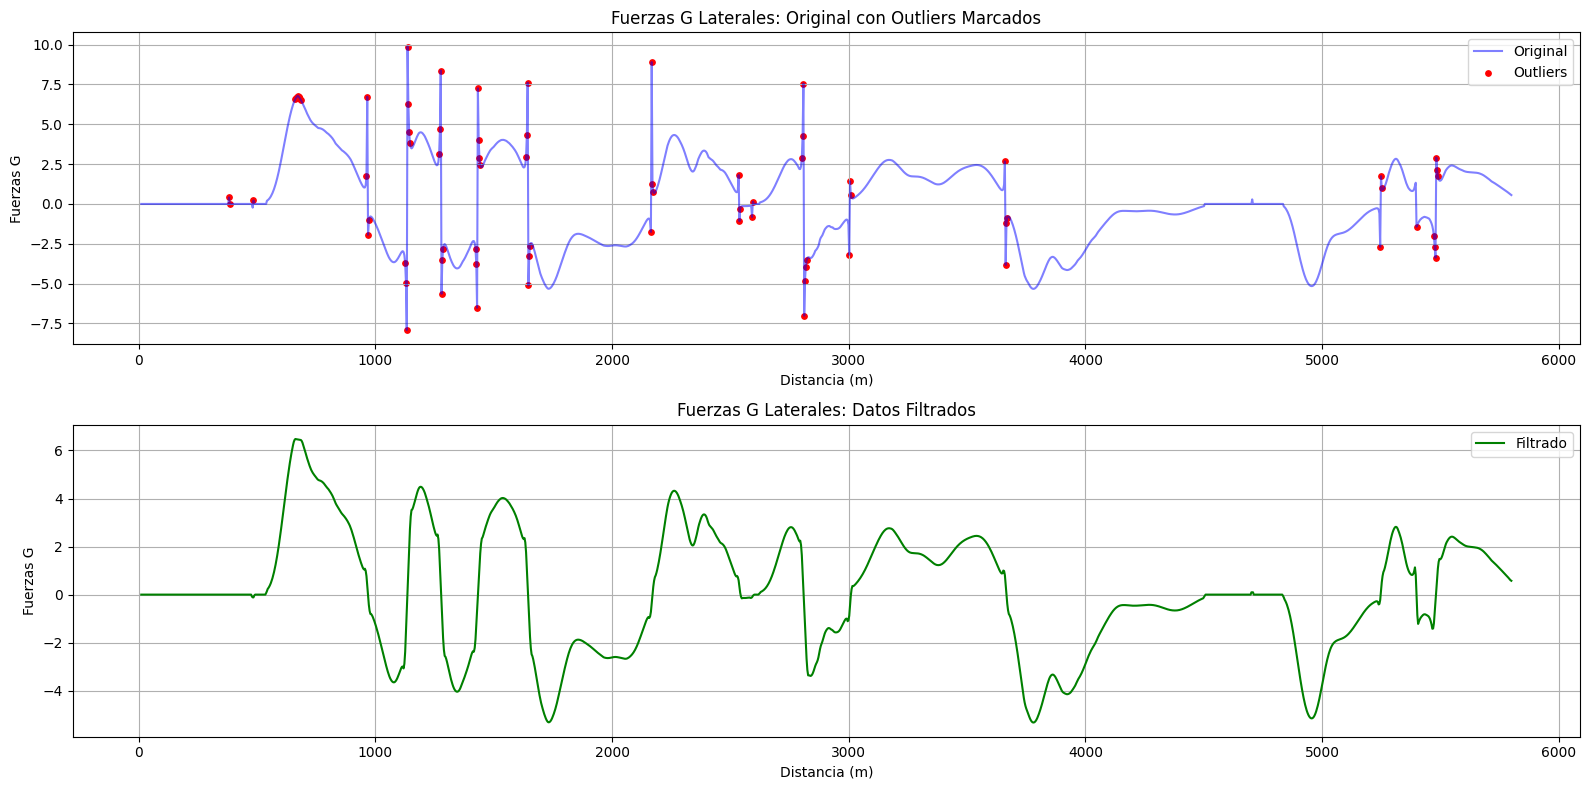

In [15]:
# Aplicar la función a tu DataFrame df_combined
df_cleaned =df_combined_driver1.copy()

plt.figure(figsize=(16, 8))

# Gráfica de fuerzas G originales
plt.subplot(2, 1, 1)
plt.plot(df_cleaned['Distance'], df_cleaned['Lateral_G'], color='blue', alpha=0.5, label='Original')
# Marcar los outliers
plt.scatter(df_cleaned.loc[df_cleaned['lateral_g_outlier'], 'Distance'], 
            df_cleaned.loc[df_cleaned['lateral_g_outlier'], 'Lateral_G'], 
            color='red', s=15, label='Outliers')
plt.title('Fuerzas G Laterales: Original con Outliers Marcados')
plt.xlabel('Distancia (m)')
plt.ylabel('Fuerzas G')
plt.grid(True)
plt.legend()

# Gráfica de fuerzas G filtradas
plt.subplot(2, 1, 2)
plt.plot(df_cleaned['Distance'], df_cleaned['lateral_g_filtered'], color='green', label='Filtrado')
plt.title('Fuerzas G Laterales: Datos Filtrados')
plt.xlabel('Distancia (m)')
plt.ylabel('Fuerzas G')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
df_combined = merge_on_nearest_time(fl1_tel_xy, fl1_tel_interpolated, time_col='Time')
df_combined = calibrate_xy_coordinates(df_combined, distance_col='Distance')
df_combined = verify_scaling(df_combined)
df_scaled = df_combined.copy()
df_combined = interpolate_xy(df_combined)
df_combined['X'] = df_combined['X_scaled']
df_combined['Y'] = df_combined['Y_scaled']

'''


df_combined['radio_recalculated_corrected'] = compute_radius(df_combined['X_scaled'], df_combined['Y_scaled'],window_size=150)
df_combined['radio_final'] = compute_radius(df_combined['X_scaled'], df_combined['Y_scaled'],window_size=150)

df_resultado = calcular_aceleracion_lateral(df_combined, speed_col='Speed', radio_col='radio_final')
'''




Factor de escala calculado: 0.1007
Distancia real total: 5789.00 metros
Distancia euclidiana total: 57508.44 unidades
Después de escalar:
Distancia real total: 5789.00 metros
Distancia euclidiana escalada total: 5789.00 unidades
Error de escala: 0.00 metros (0.00%)
Interpolando datos con factor 5x...
Rango de distancia original: 11.00 a 5800.00 metros
Interpolación paramétrica completada: 1735 puntos generados












































































































































































































































































































































































































































































































































































































C:\Users\Danie\AppData\Local\Temp\ipykernel_23452\3470702605.py:247: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'pos' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



"df_combined.to_csv('fl1_tel_interpolated.csv', index=False)\ndf_combined = interpolate_xy(df_combined)\ndf_combined = calibrate_xy_coordinates(df_combined, distance_col='Distance')\ndf_combined = verify_scaling(df_combined)\n\ndf_combined['radio_recalculated_corrected'] = compute_radius(df_combined['X_scaled'], df_combined['Y_scaled'],window_size=150)\ndf_combined['radio_final'] = compute_radius(df_combined['X_scaled'], df_combined['Y_scaled'],window_size=150)\n\ndf_resultado = calcular_aceleracion_lateral(df_combined, speed_col='Speed', radio_col='radio_final')\n\ndf_resultado = df_resultado.dropna()\ndf_resultado.reset_index(drop=True, inplace=True)\n\nfig = go.Figure()\nfig.add_trace(go.Scatter(x=df_resultado['Distance'], y=df_resultado['aceleracion_lateral'], mode='lines', name='Sainz', line=dict(color='red')))  "

In [10]:
# Ejemplo de uso:
df_combined['radio_final'] = df_combined['Radius']
df_combined['aceleracion_lateral'] = df_combined['Lateral_G']
df_combined['X_scaled'] = df_combined['X']
df_combined['Y_scaled'] = df_combined['Y']
fig_track_speed, fig_track_g = visualize_track_telemetry(df_combined)

# Mostrar las figuras:
fig_track_speed.show()
fig_track_g.show()

In [1]:
df_resultado.to_csv('resultado.csv', index=True)

NameError: name 'df_resultado' is not defined

In [42]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Definir las posiciones de los sectores
sector1_end = 2000  # Fin del sector 1 en metros
sector2_end = 4000  # Fin del sector 2 en metros
# El sector 3 termina al final de la vuelta (5451m)

track_length = 5807  # Longitud total de la pista en metros

# Definir las posiciones de las curvas principales
# Formato: [posición en metros, número de curva]
track_corners = [
    [400, 1],
    [500, 2],
    [600, 3],
    [1000, 4],
    [1300, 5],
    [1700, 6],
    [2000, 7],
    [2600, 8],
    [2900, 9],
    [3200, 10],
    [3500, 11],
    [4000, 12]
]

# Extraer solo las posiciones de las curvas para las grid lines
corner_positions = [corner[0] for corner in track_corners]

# Modificar la estructura de subplots para tener 4 gauge charts en la primera fila
fig = make_subplots(
        rows=4, 
        cols=4,  # Cambiar a 4 columnas para los gauge charts
        row_heights=[.7, 5, 1, 2], 
        shared_xaxes=True,
        specs=[
            # Primera fila: 4 indicadores separados
            [{"type": "indicator"}, {"type": "indicator"},{"type": "indicator"}, {"type": "indicator"}],
            # Segunda fila en adelante: gráficos que abarcan todas las columnas
            [{"colspan": 4}, None, None, None],     
            [{"colspan": 4}, None, None, None],     
            [{"colspan": 4}, None, None, None]     
        ], 
        vertical_spacing=0.05)

fig.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white'),
    margin=dict(t=200, l=50, r=50, b=50),
    height=1080,
    width=1920,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1
    )
)

# Calcular los valores promedio de acelerador y freno para cada piloto
sainz_throttle_avg = fl1_tel_interpolated['Throttle'].mean()
hamilton_throttle_avg = fl2_tel_interpolated['Throttle'].mean()
sainz_brake_avg = fl1_tel_interpolated['Brake'].mean()
hamilton_brake_avg = fl2_tel_interpolated['Brake'].mean()

# Calcular estadísticas para ambos pilotos
def calculate_stats(telemetry_df):
    stats = {}
    # Porcentaje de tiempo con acelerador a fondo (>90%)
    stats['full_throttle_pct'] = (telemetry_df['Throttle'] == 100).mean() * 100
    print(stats['full_throttle_pct'])
    print((telemetry_df['Throttle'] == 100).mean() * 100)
    print((telemetry_df['Throttle'] == 100).mean())
    # Porcentaje de tiempo frenando (>10%)
    stats['braking_pct'] = (telemetry_df['Brake'] > .9).mean() * 100
    
    # Velocidad media
    stats['avg_speed'] = telemetry_df['Speed'].mean()
    
    # Velocidad máxima
    stats['max_speed'] = telemetry_df['Speed'].max()
    return stats

driver1_stats = calculate_stats(fl1_tel_interpolated)
driver2_stats = calculate_stats(fl2_tel_interpolated)
print(driver1_stats)
print(driver2_stats)

fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=driver1_stats['full_throttle_pct'],
        title={"text": "Full Throttle %", "font": {"color": "white", "size": 14}},
        delta = {'reference': driver2_stats['full_throttle_pct']},
        gauge={
            "axis": {
                "range": [0, 100], 
                "tickcolor": "black",
                "tickvals": [0, 20, 40, 60, 80, 100],
                "ticktext": ["", "","", "", "", ""],
                "tickfont": {"size": 8, "color": "rgba(255,255,255,1)"},
                "showticklabels": False
            },
            "bar": {"color": "green"},
            "bgcolor": "rgba(255,255,255,1)",
            "bordercolor": "white"
        },
        number={"suffix": "%", "font": {"color": "white", "size": 18}}
    ),
    row=1, col=1)

# Hamilton - Acelerador (segunda columna)
fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=hamilton_throttle_avg,
        title={"text": "Hamilton<br>Acelerador", "font": {"color": "white", "size": 14}},
        gauge={
            "axis": {"range": [0, 100], "tickcolor": "white"},
            "bar": {"color": "white"},
            "bgcolor": "rgba(0,0,0,0)",
            "bordercolor": "gray",
            "steps": [
                {"range": [0, 50], "color": "rgba(255,255,255,0.2)"},
                {"range": [50, 80], "color": "rgba(255,255,255,0.4)"},
                {"range": [80, 100], "color": "rgba(255,255,255,0.6)"}
            ]
        },
        number={"suffix": "%", "font": {"color": "white", "size": 16}}
    ),
    row=1, col=2
)

# Sainz - Freno (tercera columna)
fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=sainz_brake_avg,
        title={"text": "Sainz<br>Freno", "font": {"color": "red", "size": 14}},
        gauge={
            "axis": {"range": [0, 100], "tickcolor": "red"},
            "bar": {"color": "red"},
            "bgcolor": "rgba(0,0,0,0)",
            "bordercolor": "gray",
            "steps": [
                {"range": [0, 30], "color": "rgba(255,0,0,0.2)"},
                {"range": [30, 60], "color": "rgba(255,0,0,0.4)"},
                {"range": [60, 100], "color": "rgba(255,0,0,0.6)"}
            ]
        },
        number={"suffix": "%", "font": {"color": "red", "size": 16}}
    ),
    row=1, col=3
)

# Hamilton - Freno (cuarta columna)
fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=hamilton_brake_avg,
        title={"text": "Hamilton<br>Freno", "font": {"color": "white", "size": 14}},
        gauge={
            "axis": {"range": [0, 100], "tickcolor": "white"},
            "bar": {"color": "white"},
            "bgcolor": "rgba(0,0,0,0)",
            "bordercolor": "gray",
            "steps": [
                {"range": [0, 30], "color": "rgba(255,255,255,0.2)"},
                {"range": [30, 60], "color": "rgba(255,255,255,0.4)"},
                {"range": [60, 100], "color": "rgba(255,255,255,0.6)"}
            ]
        },
        number={"suffix": "%", "font": {"color": "white", "size": 16}}
    ),
    row=1, col=4
)



#--------IMAGENES--------

fig.add_layout_image(
    dict(
        source="Sainz.png",
        xref="paper", yref="paper",
        x=0.1,  # Centrado horizontalmente (0.5 es el centro)
        y=1.3,  # Posición ajustada para estar en el espacio superior (> 1 para estar por encima del área del gráfico)
        sizex=.2,  # Ancho de la imagen
        sizey=.2,  # Altura de la imagen
        xanchor="center",  # Centrado horizontalmente
        yanchor="middle",  # Centrado verticalmente
        opacity=1,
        layer="above"
    )
)
fig.add_layout_image(
    dict(
        source="track_performance_map.png",
        xref="paper", yref="paper",
        x=0.5,  # Centrado horizontalmente (0.5 es el centro)
        y=1.30,  # Posición ajustada para estar en el espacio superior (> 1 para estar por encima del área del gráfico)
        sizex=0.3,  # Ancho de la imagen
        sizey=0.3,  # Altura de la imagen
        xanchor="center",  # Centrado horizontalmente
        yanchor="middle",  # Centrado verticalmente
        opacity=1,
        layer="above"
    )
)










# Configurar las líneas de cuadrícula para que estén alineadas con las curvas
fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128, 128, 128, 1)',
    zeroline=False,
    dtick=None,  # Eliminamos el dtick predeterminado
    tickvals=corner_positions,  # Usar las posiciones de las curvas para las líneas verticales
    ticktext=["" for _ in corner_positions]  # Texto vacío para no mostrar etiquetas numéricas
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128, 128, 128, 0.3)',
    zeroline=False
)

# Añadir líneas verticales para los sectores específicamente en la gráfica de speed (row=2, col=1)
fig.add_shape(
    type="line",
    x0=sector1_end, y0=0,
    x1=sector1_end, y1=1,
    line=dict(color="yellow", width=1, dash="dash"),
    xref="x", yref="y2 domain",  # Referencia al dominio del segundo subplot (speed plot)
    row=2, col=1  # Especificar explícitamente el subplot
)

fig.add_shape(
    type="line",
    x0=sector2_end, y0=0,
    x1=sector2_end, y1=1,
    line=dict(color="yellow", width=1, dash="dash"),
    xref="x", yref="y2 domain",  # Referencia al dominio del segundo subplot (speed plot)
    row=2, col=1  # Especificar explícitamente el subplot
)

# Añadir etiquetas para los sectores en la parte superior del gráfico
fig.add_annotation(
    x=sector1_end/2, 
    y=1.01,
    xref="x", 
    yref="paper",
    text="Sector 1",
    showarrow=False,
    font=dict(color="yellow", size=14),
)

fig.add_annotation(
    x=(sector1_end + sector2_end)/2, 
    y=1.01,
    xref="x", 
    yref="paper",
    text="Sector 2",
    showarrow=False,
    font=dict(color="yellow", size=14),
)

fig.add_annotation(
    x=(sector2_end + track_length)/2, 
    y=1.01,
    xref="x", 
    yref="paper",
    text="Sector 3",
    showarrow=False,
    font=dict(color="yellow", size=14),
)

# Obtener el rango de velocidades para posicionar las etiquetas
try:
    speed_min = min(fl1_tel['Speed'].min(), fl2_tel['Speed'].min())
    speed_max = max(fl1_tel['Speed'].max(), fl2_tel['Speed'].max())
    # Posicionar las etiquetas en la parte inferior del gráfico de velocidad
    label_y_pos = speed_min - (speed_max - speed_min) * 0.08  # Reducido el espacio para etiquetas horizontales
except:
    # En caso de error, usar un valor predeterminado
    label_y_pos = 0

















# Añadir etiquetas horizontales para cada curva en la sección de velocidad
for corner in track_corners:
    position, number = corner
    
    # Añadir etiqueta para el número de curva (ahora horizontal)
    fig.add_annotation(
        x=position,
        y=label_y_pos,  # Ajustado para texto horizontal
        text=f"T{number}",  # "T" de "Turn"
        showarrow=False,
        font=dict(color="cyan", size=10),
        xref="x", 
        yref="y1",
        bgcolor="rgba(0,0,0,1)",
        yshift=0,  # Ajustado para texto horizontal
        xshift=0,
        textangle=0,  # Texto horizontal
        row=2, col=1
    )



















# Speed plot
'''fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Speed'],
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    name='Sainz',
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,
    col=1
)'''
fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Speed'],
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    name='Sainz',
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,  # Asegúrate que este valor es correcto
    col=1
)
fig.add_trace(go.Scatter(
    y=fl2_tel_interpolated['Speed'],
    x=fl2_tel_interpolated['Distance'],
    mode='lines',
    name='Hamilton',
    line=dict(color='white', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,
    col=1
)
# Throttle plot
fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Throttle'], 
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='red', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=2, 
    col=1
)

fig.add_trace(go.Scatter(
    y=fl2_tel_interpolated['Throttle'], 
    x=fl2_tel_interpolated['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='white', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=2, 
    col=1
)




#DELTA TIME PLOT--------------------

# Añadir una línea horizontal en y=0 en el subplot del delta de tiempo
fig.add_shape(
    type="line",
    x0=delta_df_interpolated['Distance'].min(),
    y0=0,
    x1=delta_df_interpolated['Distance'].max(),
    y1=0,
    line=dict(color="white", width=1, dash="dash"),
    row=3,
    col=1,
    xref="x",
    yref="y2"
)
# Añadir una línea horizontal en y=0 en el subplot del delta de tiempo
fig.add_shape(
    type="line",
    x0=delta_df_interpolated['Distance'].min(),
    y0=0,
    x1=delta_df_interpolated['Distance'].max(),
    y1=0,
    line=dict(color="white", width=.3, dash="dash"),
    row=3,
    col=1,
    xref="x",
    yref="y3"
)

'''# Añadir una línea horizontal en y=0 en el subplot del delta de tiempo
fig.add_shape(
    type="line",
    x0=delta_df_interpolated['Distance'].min(),
    y0=0,
    x1=delta_df_interpolated['Distance'].max(),
    y1=0,
    line=dict(color="white", width=1, dash="dash"),
    row=3,
    col=1,
    xref="x",
    yref="y4"
)'''

# Añadir anotaciones explicativas para el delta de tiempo
delta_max = delta_df_interpolated['DeltaTime'].max()
delta_min = delta_df_interpolated['DeltaTime'].min()
y_pos_top = delta_max + (delta_max - delta_min) * 0.1
y_pos_bottom = delta_min - (delta_max - delta_min) * 0.1

# Versión más eficiente para el gráfico de delta con colores
# Preparar los datos para segmentos
segments = []
current_segment = {'x': [], 'y': [], 'color': None}

# Definir color inicial
last_color = 'white' if delta_df_interpolated['DeltaTime'].iloc[0] > 0 else 'red'
current_segment['color'] = last_color
current_segment['x'].append(delta_df_interpolated['Distance'].iloc[0])
current_segment['y'].append(delta_df_interpolated['DeltaTime'].iloc[0])

# Agrupar puntos consecutivos del mismo color
for i in range(1, len(delta_df_interpolated)):
    current_delta = delta_df_interpolated['DeltaTime'].iloc[i]
    current_dist = delta_df_interpolated['Distance'].iloc[i]
    
    # Determinar el color actual
    current_color = 'white' if current_delta > 0 else 'red'
    
    # Si cambia el color, terminar el segmento actual y comenzar uno nuevo
    if current_color != last_color:
        # Añadir el punto actual al segmento anterior para evitar gaps
        current_segment['x'].append(current_dist)
        current_segment['y'].append(current_delta)
        
        # Guardar el segmento completo
        segments.append(current_segment)
        
        # Iniciar nuevo segmento con el punto actual
        current_segment = {'x': [current_dist], 'y': [current_delta], 'color': current_color}
        last_color = current_color
    else:
        # Añadir el punto al segmento actual
        current_segment['x'].append(current_dist)
        current_segment['y'].append(current_delta)

# Añadir el último segmento
if current_segment['x']:
    segments.append(current_segment)

# Añadir cada segmento como un trazo separado
for i, segment in enumerate(segments):
    fig.add_trace(go.Scatter(
        y=segment['y'], 
        x=segment['x'],
        mode='lines',
        line=dict(color=segment['color'], width=1),
        hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Delta:</b> %{y:.3f}s<extra></extra>',
        showlegend=False),
        row=3, 
        col=1
    )

# Añadir entradas para la leyenda
fig.add_trace(go.Scatter(
    y=[None], 
    x=[None],
    mode='lines',
    line=dict(color='white', width=2),
    name='Hamilton más rápido'),
    row=2, 
    col=1
)

fig.add_trace(go.Scatter(
    y=[None], 
    x=[None],
    mode='lines',
    line=dict(color='red', width=2),
    name='Sainz más rápido'),
    row=2, 
    col=1
)





# Brake plot
fig.add_trace(go.Scatter(
    y=df_combined_driver1['longitudinal_aceleration'], 
    x=df_combined_driver1['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='orange', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Brake:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)

fig.add_trace(go.Scatter(
    y=df_combined_driver2['longitudinal_aceleration'], 
    x=df_combined_driver2['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='green', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Brake:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)


fig.add_trace(go.Scatter(
    y=df_combined_driver1['lateral_g_filtered'], 
    x=df_combined_driver1['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='red', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)
# Throttle plot
fig.add_trace(go.Scatter(
    y=df_combined_driver2['lateral_g_filtered'], 
    x=df_combined_driver2['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='white', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)










# Ajustar el rango de visualización del gráfico de velocidad para dejar espacio para las etiquetas horizontales
fig.update_yaxes(range=[label_y_pos - 10, speed_max * 1.05], row=1, col=1)
# Añadir título principal
fig.add_annotation(
    xref='paper',
    yref='paper',
    x=0.5,
    y=1.35,
    text="Titulo ejemplo",
    showarrow=False,
    font=dict(color="white", size=24, family="Arial Black"),
    align="center"
)




add_speed_annotations(
    fig, 
    fl1_tel_interpolated['Distance'].values,  # x1 (Sainz)
    fl1_tel_interpolated['Speed'].values,     # y1 (Sainz)
    fl2_tel_interpolated['Distance'].values,  # x2 (Hamilton)
    fl2_tel_interpolated['Speed'].values,     # y2 (Hamilton)
    'Sainz',                                 # name1
    'Hamilton',                              # name2
    'red',                                   # color1 
    'white',                                 # color2
    offset=20,                               # desplazamiento vertical
    min_peak_speed=250,                      # velocidad mínima para mostrar picos
    row=1                                    # Asegúrate que este valor es correcto
)















# Apply to all subplot rows
# Añadir títulos a los ejes y para cada subplot
fig.update_yaxes(title_text="Speed (km/h)",title_font_size=10, color='white', row=2, col=1)
fig.update_yaxes(title_text="Delta Time (s)",title_font_size=10, color='white', row=3, col=1)
fig.update_yaxes(title_text="Throttle (%)",title_font_size=10, color='white', row=4, col=1)
fig.update_yaxes(title_text="Brake (On/Off)",title_font_size=10, color='white', row=5, col=1)
fig.update_yaxes(title_text="Gear",title_font_size=10, color='white', row=6, col=1)
fig.update_xaxes(title_text="Distance (m)", color='white', row=6, col=1)

# Añadir títulos a los ejes y para cada subplot con alineación consistente
fig.update_yaxes(
    title=dict(
        text="Speed (km/h)",
        font=dict(size=10, color='white'),
        standoff=0   # Distancia entre el título y el eje
    ),
    title_standoff=25,   # Distancia consistente para todos los títulos
    row=2, col=1
)

fig.update_yaxes(
    title=dict(
        text="Delta Time (s)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=3, col=1
)

fig.update_yaxes(
    title=dict(
        text="Throttle (%)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=4, col=1
)

fig.update_yaxes(
    title=dict(
        text="Brake (On/Off)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=5, col=1
)

fig.update_yaxes(
    title=dict(
        text="Gear",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=6, col=1
)

fig.update_xaxes(
    title=dict(
        text="Distance (m)",
        font=dict(size=10, color='white')
    ),
    row=6, col=1
)

# Mostrar la gráfica
fig.show()

70.72498708455312
70.72498708455312
0.7072498708455313
69.01724137931035
69.01724137931035
0.6901724137931035
{'full_throttle_pct': 70.72498708455312, 'braking_pct': 6.784914758050628, 'avg_speed': 250.36679706512226, 'max_speed': 330.9800203124756}
{'full_throttle_pct': 69.01724137931035, 'braking_pct': 8.086206896551724, 'avg_speed': 249.53947625618812, 'max_speed': 329.0}


In [11]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

def create_track_performance_map(filled_delta_df, fast_df, slow_df, track_name="Track", csv_path="coords.csv", min_segments=3, total_track_length=5451):
    """
    Crea un mapa del circuito que muestra qué piloto es más rápido en cada sección,
    asegurando que no haya huecos en la visualización, incluyendo el segmento entre el final y el inicio.
    
    Args:
        filled_delta_df: DataFrame con la columna 'Fastest'
        fast_df: DataFrame del piloto más rápido
        slow_df: DataFrame del piloto más lento
        track_name: Nombre del circuito
        csv_path: Ruta al archivo CSV con las coordenadas
        min_segments: Número mínimo de segmentos consecutivos para cambiar el color
        total_track_length: Longitud total del circuito en metros (default: 5451m)
    """
    # [Código existente para cargar coordenadas y normalizar]
    # Cargar coordenadas desde el archivo CSV
    track_coords = pd.read_csv(csv_path)
    
    # Extraer coordenadas x, y
    x_coords = track_coords['x'].values
    y_coords = track_coords['y'].values
    
    # Calcular mínimos y máximos
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    
    # Normalizar coordenadas a un rango [0,1] para x e y
    x_norm = [(x - x_min)/(x_max - x_min) for x in x_coords]
    y_norm = [(y - y_min)/(y_max - y_min) for y in y_coords]
    
    # Cerrar el circuito: añadir el primer punto al final si no está cerrado
    if (x_norm[0] != x_norm[-1]) or (y_norm[0] != y_norm[-1]):
        x_norm.append(x_norm[0])
        y_norm.append(y_norm[0])
        x_coords = np.append(x_coords, x_coords[0])
        y_coords = np.append(y_coords, y_coords[0])
    
    # Calcular la longitud del circuito en segmentos
    track_segments = len(x_norm) - 1
    
    # [Resto del código para calcular distancias]
    # Calcular las distancias acumuladas a lo largo del circuito
    segment_lengths = []
    total_length = 0
    
    for i in range(track_segments):
        # Calcular la distancia euclidiana entre puntos consecutivos
        dx = x_coords[i+1] - x_coords[i]
        dy = y_coords[i+1] - y_coords[i]
        segment_length = np.sqrt(dx**2 + dy**2)
        segment_lengths.append(segment_length)
        total_length += segment_length
    
    # Normalizar las longitudes de segmentos para que la suma sea total_track_length
    scale_factor = total_track_length / total_length
    segment_lengths = [length * scale_factor for length in segment_lengths]
    
    # Calcular las distancias acumuladas en metros
    cumulative_distances = [0]
    for length in segment_lengths:
        cumulative_distances.append(cumulative_distances[-1] + length)

    
    # Aseguramos que los datos están ordenados por distancia
    filled_delta_df = filled_delta_df.sort_values('Distance').reset_index(drop=True)
    fast_df = fast_df.sort_values('Distance').reset_index(drop=True)
    slow_df = slow_df.sort_values('Distance').reset_index(drop=True)

    
    
    # Identificar si fast_df es Hamilton o Sainz
    # Asumimos que si el delta final es positivo, entonces Hamilton es fast_df
    hamilton_is_fast = True if 'DeltaTime' in filled_delta_df.columns and filled_delta_df['DeltaTime'].iloc[-1] > 0 else False
    
    # [Código para determinar quién es más rápido en cada segmento]
    # Para cada segmento del circuito, determinar quién es más rápido
    segment_fastest = []
    segment_hamilton_speed = []
    segment_sainz_speed = []
    
    for i in range(track_segments):
        # Obtener el rango de distancia para este segmento
        start_dist = cumulative_distances[i]
        end_dist = cumulative_distances[i+1]
        mid_dist = (start_dist + end_dist) / 2
        
        # Manejar el caso especial del último segmento que conecta con el inicio
        if i == track_segments - 1 and start_dist > filled_delta_df['Distance'].max():
            # Para el segmento que cierra el circuito, usar el primer y último punto de datos
            fast_start_idx = fast_df['Distance'].idxmin()
            fast_end_idx = fast_df['Distance'].idxmax()
            slow_start_idx = slow_df['Distance'].idxmin()
            slow_end_idx = slow_df['Distance'].idxmax()
            
            # Calcular velocidades promedio para este segmento
            fast_speed = (fast_df.loc[fast_start_idx, 'Speed'] + fast_df.loc[fast_end_idx, 'Speed']) / 2
            slow_speed = (slow_df.loc[slow_start_idx, 'Speed'] + slow_df.loc[slow_end_idx, 'Speed']) / 2
        else:
            # Encontrar los puntos de telemetría más cercanos a esta distancia
            fast_idx = (fast_df['Distance'] - mid_dist).abs().idxmin()
            slow_idx = (slow_df['Distance'] - mid_dist).abs().idxmin()
            
            # Obtener las velocidades
            fast_speed = fast_df.loc[fast_idx, 'Speed']
            slow_speed = slow_df.loc[slow_idx, 'Speed']
        
        # Asignar velocidades a Hamilton y Sainz según quién es más rápido
        if hamilton_is_fast:
            hamilton_speed = fast_speed
            sainz_speed = slow_speed
        else:
            hamilton_speed = slow_speed
            sainz_speed = fast_speed
        
        # Determinar quién es más rápido basado en la velocidad
        speed_based_fastest = -1 if hamilton_speed > sainz_speed else 1
        
        segment_fastest.append(speed_based_fastest)
        segment_hamilton_speed.append(hamilton_speed)
        segment_sainz_speed.append(sainz_speed)
    
    # [Resto del código para crear y filtrar el DataFrame de segmentos]
    # Crear DataFrame para los segmentos
    segment_df = pd.DataFrame({
        'StartDist': cumulative_distances[:-1],
        'EndDist': cumulative_distances[1:],
        'MidDist': [(cumulative_distances[i] + cumulative_distances[i+1])/2 for i in range(track_segments)],
        'Fastest': segment_fastest,
        'HamiltonSpeed': segment_hamilton_speed,
        'SainzSpeed': segment_sainz_speed
    })
    
    # Aplicar el filtro de segmentos mínimos
    segment_df['FilteredFastest'] = segment_df['Fastest'].copy()
    
    # Inicializar con el valor del primer segmento
    current_color = segment_df.loc[0, 'Fastest']
    consecutive_count = 1
    
    # Recorrer todos los segmentos y aplicar la regla de min_segments
    for i in range(1, len(segment_df)):
        if segment_df.loc[i, 'Fastest'] == current_color:
            # Continúa la tendencia actual
            consecutive_count += 1
        else:
            # Potencial cambio de tendencia
            if consecutive_count >= min_segments:
                # La tendencia anterior era lo suficientemente larga, comienza una nueva
                current_color = segment_df.loc[i, 'Fastest']
                consecutive_count = 1
            else:
                # La tendencia anterior no era lo suficientemente larga, mantén el color anterior
                segment_df.loc[i, 'FilteredFastest'] = current_color
                consecutive_count = 1
    
    # Segundo pase: corregir segmentos intermedios que no alcanzaron min_segments
    i = 0
    while i < len(segment_df):
        current_color = segment_df.loc[i, 'FilteredFastest']
        start_i = i
        
        # Encontrar el final de este segmento
        while i < len(segment_df) and segment_df.loc[i, 'FilteredFastest'] == current_color:
            i += 1
        
        # Si este segmento es demasiado corto y no es el último, mezclarlo con el siguiente
        if i - start_i < min_segments and i < len(segment_df):
            next_color = segment_df.loc[i, 'FilteredFastest']
            
            # Si el siguiente segmento es más largo, adopta su color
            j = i
            while j < len(segment_df) and segment_df.loc[j, 'FilteredFastest'] == next_color:
                j += 1
            
            if j - i >= min_segments:
                # El siguiente segmento es lo suficientemente largo, adopta su color
                segment_df.loc[start_i:i-1, 'FilteredFastest'] = next_color
            else:
                # El siguiente segmento también es corto, mantén el color actual
                segment_df.loc[i:j-1, 'FilteredFastest'] = current_color
                i = j  # Salta al final del siguiente segmento
        # Si es el último segmento y es demasiado corto, mezclarlo con el anterior
        elif i - start_i < min_segments and i == len(segment_df) and start_i > 0:
            # Buscar el color anterior
            prev_i = start_i - 1
            prev_color = segment_df.loc[prev_i, 'FilteredFastest']
            
            # Adoptar el color anterior
            segment_df.loc[start_i:i-1, 'FilteredFastest'] = prev_color
    
    # Asegurar que el primer y último segmento tengan el mismo color si son contiguos
    # Esto evita un cambio visual donde el circuito se cierra
    if abs(segment_df.loc[0, 'StartDist'] - segment_df.loc[len(segment_df)-1, 'EndDist']) < 0.01 * total_track_length:
        # Si el primero y el último segmento son contiguos (circuito cerrado)
        # Decidir qué color usar basado en cuál es dominante
        if segment_df.loc[0, 'FilteredFastest'] == segment_df.loc[len(segment_df)-1, 'FilteredFastest']:
            # Ambos tienen el mismo color, no hay problema
            pass
        else:
            # Diferentes colores, usar el que tenga más segmentos consecutivos
            first_color = segment_df.loc[0, 'FilteredFastest']
            last_color = segment_df.loc[len(segment_df)-1, 'FilteredFastest']
            
            first_count = 1
            i = 1
            while i < len(segment_df) and segment_df.loc[i, 'FilteredFastest'] == first_color:
                first_count += 1
                i += 1
            
            last_count = 1
            i = len(segment_df) - 2
            while i >= 0 and segment_df.loc[i, 'FilteredFastest'] == last_color:
                last_count += 1
                i -= 1
            
            if first_count >= last_count:
                segment_df.loc[len(segment_df)-1, 'FilteredFastest'] = first_color
            else:
                segment_df.loc[0, 'FilteredFastest'] = last_color

    return segment_df,track_segments,x_norm,y_norm
    

        


segment_df,track_segments,x_norm,y_norm = create_track_performance_map(filled_delta_df, fast_df, slow_df, min_segments=3)

# [Código existente para configurar la figura]
# Crear figura para el mapa
fig_map = go.Figure()

# Establecer fondo negro
fig_map.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    width=1000,
    height=800,

    margin=dict(t=100, l=50, r=50, b=50),
    showlegend=False,
)
# [Código para dibujar los segmentos]
# Colorear cada segmento según el valor de 'FilteredFastest'
for i in range(track_segments):
    # Obtener el valor filtrado para este segmento
    fastest_value = segment_df.loc[i, 'FilteredFastest']
    
    # Determinar el color según quién es más rápido
    # Nota: -1 = Hamilton más rápido, 1 = Sainz más rápido
    if fastest_value == -1:  # Hamilton más rápido
        color = 'rgb(255,255,255)'  # Blanco
        faster_driver = "Hamilton más rápido"
    else:  # Sainz más rápido
        color = 'rgb(255,0,0)'  # Rojo
        faster_driver = "Sainz más rápido"
    
    # Obtener datos para el tooltip
    segment_dist = segment_df.loc[i, 'MidDist']
    segment_length = segment_df.loc[i, 'EndDist'] - segment_df.loc[i, 'StartDist']
    hamilton_speed = segment_df.loc[i, 'HamiltonSpeed']
    sainz_speed = segment_df.loc[i, 'SainzSpeed']
    
    # Calcular la diferencia de velocidad
    speed_diff = hamilton_speed - sainz_speed
    
    # Añadir segmento con tooltip mejorado
    fig_map.add_trace(go.Scatter(
        x=[x_norm[i], x_norm[i+1]],
        y=[y_norm[i], y_norm[i+1]],
        mode='lines',
        line=dict(color=color, width=5),
        hovertemplate=(
            f"Segmento {i+1}<br>" +
            f"Distancia: {segment_dist:.0f}m<br>" +
            f"Longitud: {segment_length:.1f}m<br>" +
            f"Hamilton: {hamilton_speed:.1f} km/h<br>" +
            f"Sainz: {sainz_speed:.1f} km/h<br>" +
            f"Diferencia: {abs(speed_diff):.1f} km/h<br>" +
            f"{faster_driver}" +
            "<extra></extra>"
        ),
        showlegend=False
    ))

# [Resto del código para las curvas, leyendas y estadísticas]
# Detectar puntos clave del circuito (curvas importantes)
# Usamos los cambios de dirección para identificar curvas


# [Código existente para leyendas y estadísticas]
# Añadir leyenda para los colores
fig_map.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='markers',
    marker=dict(size=10, color='rgb(255,255,255)'),
    name='Hamilton más rápido',
))

fig_map.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='markers',
    marker=dict(size=10, color='rgb(255,0,0)'),
    name='Sainz más rápido',
))

# Calcular estadísticas usando los valores filtrados
hamilton_faster = (segment_df['FilteredFastest'] == -1)
sainz_faster = (segment_df['FilteredFastest'] == 1)


# Ajustar la leyenda
fig_map.update_layout(
    legend=dict(
        orientation="h",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.05,
        font=dict(color="white"),
        bgcolor="rgba(0,0,0,0)"
    )
)


# Eliminar ejes
fig_map.update_xaxes(visible=False)
fig_map.update_yaxes(visible=False)

# Añadir borde del circuito
fig_map.add_shape(
    type="path",
    path=f"M {x_norm[0]} {y_norm[0]} " + 
            " ".join([f"L {x} {y}" for x, y in zip(x_norm[1:], y_norm[1:])]) + 
            f" L {x_norm[0]} {y_norm[0]} Z",
    line_color="gray",
    line_width=1,
    fillcolor="rgba(0,0,0,0)"
)

fig_map.show()
fig_map.write_image("track_performance_map.png", scale=2)
    
# Ejemplo de uso



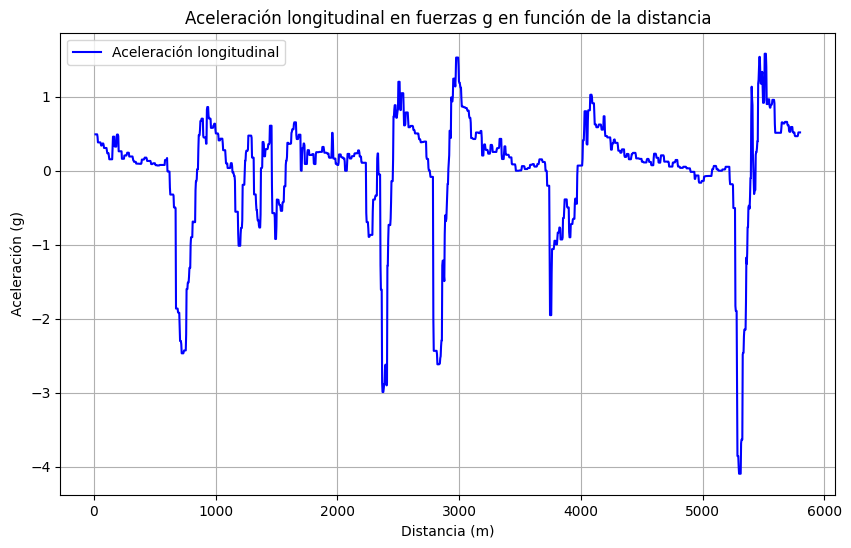

                X           Y     Distance           Z       Time  \
0     1763.000000 -723.000000    11.000000  737.000000   0.142000   
1     1763.919764 -724.061266    14.338524  736.648576   0.184171   
2     1764.839527 -725.122531    17.677047  736.297153   0.226342   
3     1765.759291 -726.183797    21.015571  735.945729   0.268512   
4     1766.679054 -727.245062    24.354095  735.594306   0.310683   
...           ...         ...          ...         ...        ...   
1730  1742.286426 -698.750278  5786.645905  745.225682  88.888459   
1731  1743.966764 -700.710671  5789.984429  744.669262  88.921844   
1732  1745.647101 -702.671065  5793.322953  744.112841  88.955230   
1733  1747.327438 -704.631458  5796.661476  743.556421  88.988615   
1734  1749.007775 -706.591851  5800.000000  743.000000  89.022000   

      DistanceToDriverAhead       Speed  nGear           RPM  Throttle  ...  \
0                169.566111  280.168421    7.0  11085.028080     100.0  ...   
1            

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Ejemplo de dataframe (reemplaza con tu data real)
data = {
    'speed': [300, 301, 302, 303, 304],  # km/h
    'distance': [1000, 1001, 1002, 1003, 1004],  # metros
    'time': [30.000, 30.033, 30.066, 30.099, 30.132]  # segundos
}
df = df_combined.copy()

# Convertir velocidad de km/h a m/s
df['speed_ms'] = df['Speed'] * (5 / 18)

# Calcular diferencias (Delta v y Delta t)
df['delta_v'] = df['speed_ms'].diff()  # Diferencia de velocidad
df['delta_t'] = df['Time'].diff()      # Diferencia de tiempo

# Calcular aceleración en m/s²
df['acceleration_ms2'] = df['delta_v'] / df['delta_t']

# Convertir aceleración a fuerzas g (1 g = 9.81 m/s²)
df_combined['longitudinal_aceleration'] = df['acceleration_ms2'] / 9.81
df['acceleration_g'] = df['acceleration_ms2'] / 9.81

# Graficar aceleración en g vs distancia
plt.figure(figsize=(10, 6))
plt.plot(df['Distance'], df['acceleration_g'], label='Aceleración longitudinal', color='blue')
plt.xlabel('Distancia (m)')
plt.ylabel('Aceleración (g)')
plt.title('Aceleración longitudinal en fuerzas g en función de la distancia')
plt.grid(True)
plt.legend()
plt.show()

# Mostrar dataframe (opcional)
print(df)

In [66]:
df_combined['lateral_g_filtered'] = df_cleaned['lateral_g_filtered']

In [17]:

fig = go.Figure()
fig.update_layout(
    width=1200,  # Ancho en píxeles
    height=800   # Alto en píxeles
)
fig.add_scatter(
    x=df_combined_driver1['lateral_g_filtered'],
    y=df_combined_driver1['longitudinal_aceleration'],
    mode='markers',
    name='Aceleración Longitudinal (g)',
    line=dict(color='blue', width=2),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Acceleration:</b> %{y:.2f}g<extra></extra>'
)

fig.show()